### Notebook
- **Name:** `cs_line_profile.ipynb`
- **Created/updated:** 2026-02-27
- **Python:** 3.x

### Purpose
Compute and export the line/corridor profile based on the DEM and line trace.

### Inputs
DEM raster(s), line trace (`.shp`), and optional tower/support layers.

### Outputs
Line profile tables/plots and GIS exports (e.g., CSV/GeoPackage/Shapefile).

### Dependencies
- (see imports below)

### Usage
Executed by the project pipeline (e.g., via Papermill) or run interactively in Jupyter.

### Notes
- Keep paths and parameters centralized in `config.toml` / `CONFIG_PATH` where applicable.


In [1]:
# Parameters (Papermill)
CONFIG_PATH = r"E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml" # "config.toml" #"config.toml"
PROJECT_ROOT = r"E:\mario\python\criticalspam"

### Generate the line profile


In [2]:
import sys
print(sys.version)
print(sys.executable)

3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]
c:\Python\Python312\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from dataclasses import dataclass

import tomllib

In [4]:
# Ruta al directorio raíz del proyecto (sube 1 nivel desde notebooks/)
#ROOT = Path.cwd().resolve().parent

# Añade src/ al path de importación
SRC = PROJECT_ROOT + r"\src"
print(f"Adding to sys.path: {SRC}")

# Imprimer CONFIG_PATH para verificar que es correcto
print(f"Using config path: {CONFIG_PATH}")

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Ya puedes importar
from cs_utils import Config, join_base, load_config_toml

Adding to sys.path: E:\mario\python\criticalspam\src
Using config path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml


In [5]:
cfg = load_config_toml(CONFIG_PATH)

print("cs_line_profile.ipynb")
print("Config path:", CONFIG_PATH)


cs_line_profile.ipynb
Config path: E:\mario\trabajos2\viesgo_edp_portugal_cic\estudios_microclimaticos\Corredoria_Grado_1_y_2\config.toml


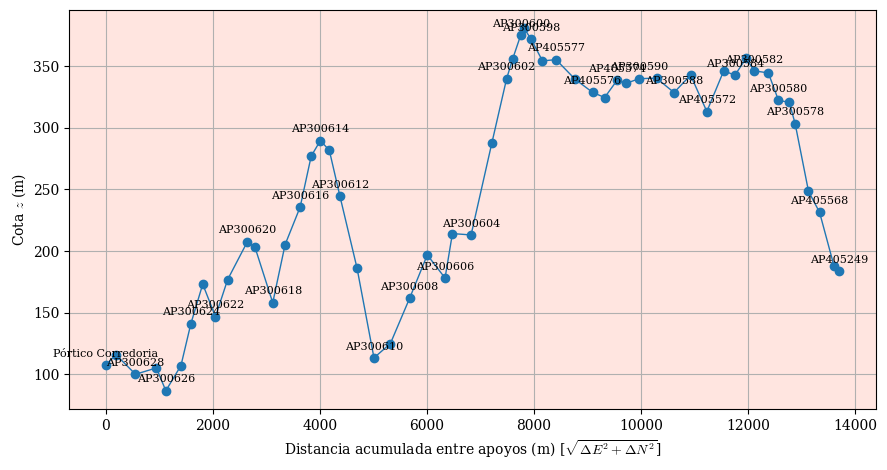

In [6]:


def parse_number(value) -> float:
    """
    Convierte a float:
    - Si viene como número de Excel (int/float), lo convierte directamente.
    - Si viene como string, acepta:
        1.234.567,89  (EU)
        1234567,89    (EU sin miles)
        1234567.89    (US)
        1.234.567     (miles)
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        raise ValueError("Valor vacío/NaN")

    if isinstance(value, (int, float)) and not isinstance(value, bool):
        return float(value)

    s = str(value).strip()
    if s == "":
        raise ValueError("Cadena vacía")

    s = s.replace(" ", "").replace("'", "")

    if "," in s and "." in s:      # EU: miles '.' + decimal ','
        return float(s.replace(".", "").replace(",", "."))
    if "," in s and "." not in s:  # EU: coma decimal
        return float(s.replace(",", "."))
    if "." in s and s.count(".") > 1:  # puntos como miles
        return float(s.replace(".", ""))

    return float(s)

def parse_xyz_with_autoscale(value, kind: str) -> float:
    """
    Corrige el caso típico de Excel “sin decimales” donde el valor real está en milésimas.
    Elige la versión que cae en rango plausible para coordenadas UTM/altitud.
    """
    v = parse_number(value)

    ranges = {
        "x": (100_000.0, 900_000.0),     # Easting UTM (m)
        "y": (0.0, 10_000_000.0),        # Northing UTM (m)
        "z": (-500.0, 9_000.0),          # cota (m) (ajusta si procede)
    }
    lo, hi = ranges[kind]

    if lo <= v <= hi:
        return v

    v1 = v / 1000.0
    if lo <= v1 <= hi:
        return v1

    return v  # si no encaja, lo devuelves para detectar anomalías

# --- Lectura y parseo ---
xlsx_path = cfg.in_xlsx # Path("Apoyos Corredoria-Grado.xlsx")
df = pd.read_excel(xlsx_path, engine="openpyxl")
df.columns = [str(c).strip() for c in df.columns]

col_x, col_y, col_z, matricula = "X", "Y", "Z", "Structure Comment"
work = df.copy()
work["x_m"] = work[col_x].apply(lambda v: parse_xyz_with_autoscale(v, "x"))
work["y_m"] = work[col_y].apply(lambda v: parse_xyz_with_autoscale(v, "y"))
work["z_m"] = work[col_z].apply(lambda v: parse_xyz_with_autoscale(v, "z"))
work = work[np.isfinite(work["x_m"]) & np.isfinite(work["y_m"]) & np.isfinite(work["z_m"])].reset_index(drop=True)

# --- Distancia acumulada en planta y perfil ---
dx = work["x_m"].diff()
dy = work["y_m"].diff()
work["d_xy_m"] = np.sqrt(dx**2 + dy**2).fillna(0.0)
work["s_xy_m"] = work["d_xy_m"].cumsum()
# Labeling
label_col = "Structure Comment" if "Structure Comment" in work.columns else ("Structure" if "Structure" in work.columns else None)
work["apoyo"] = work[label_col].astype(str).str.strip() if label_col else [f"{i+1}" for i in range(len(work))]


mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math
})


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.8))

# Fondo
fig.patch.set_facecolor("white")      # exterior (ticks, labels, márgenes)
ax.set_facecolor("#ffe5e0")           # interior (salmón claro)



ax.plot(
    work["s_xy_m"],
    work["z_m"],
    marker="o",
    linewidth=1,
)

# Etiquetas en LaTeX
ax.set_xlabel(r"Distancia acumulada entre apoyos (m) [$\sqrt{\Delta E^2 + \Delta N^2}$]")
ax.set_ylabel(r"Cota $z$ (m)")

# Etiquetado de apoyos
n = len(work)
step = max(1, n // 20)

for i in range(0, n, step):
    ax.annotate(
        work["apoyo"].iloc[i],
        (work["s_xy_m"].iloc[i], work["z_m"].iloc[i]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )

ax.grid(True)

plt.tight_layout()

# Guardado vectorial (recomendado)
plt.savefig("perfil_longitudinal.pdf", bbox_inches="tight")
# Alternativa:
# plt.savefig("perfil_longitudinal.pgf")  # integración directa con LaTeX

plt.show()



In [7]:
# Índices de los extremos
idx_max = work["z_m"].idxmax()
idx_min = work["z_m"].idxmin()

# Valores
altura_max = work.loc[idx_max, "z_m"]
altura_min = work.loc[idx_min, "z_m"]

# Apoyos asociados
apoyo_max = work.loc[idx_max, "apoyo"]
apoyo_min = work.loc[idx_min, "apoyo"]

# Desnivel
desnivel = altura_max - altura_min

# Salida formateada
print(f"Altura máxima: {altura_max:.2f} m (Apoyo: {apoyo_max})")
print(f"Altura mínima: {altura_min:.2f} m (Apoyo: {apoyo_min})")
print(f"Desnivel: {desnivel:.2f} m")

Altura máxima: 380.89 m (Apoyo: AP300599)
Altura mínima: 86.69 m (Apoyo: AP300626)
Desnivel: 294.20 m


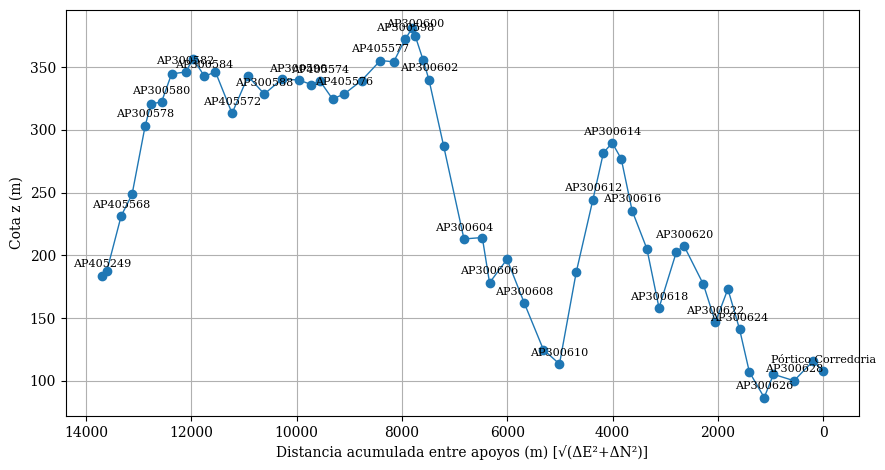

In [8]:
fig1, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(work["s_xy_m"], work["z_m"], marker="o", linewidth=1)

ax1.set_xlabel("Distancia acumulada entre apoyos (m) [√(ΔE²+ΔN²)]")
ax1.set_ylabel("Cota z (m)")

ax1.invert_xaxis()   # <-- da la vuelta al eje horizontal

n = len(work)
step = max(1, n // 20)
for i in range(0, n, step):
    ax1.annotate(work["apoyo"].iloc[i],
                (work["s_xy_m"].iloc[i], work["z_m"].iloc[i]),
                textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=8)

ax1.grid(True)
plt.tight_layout()


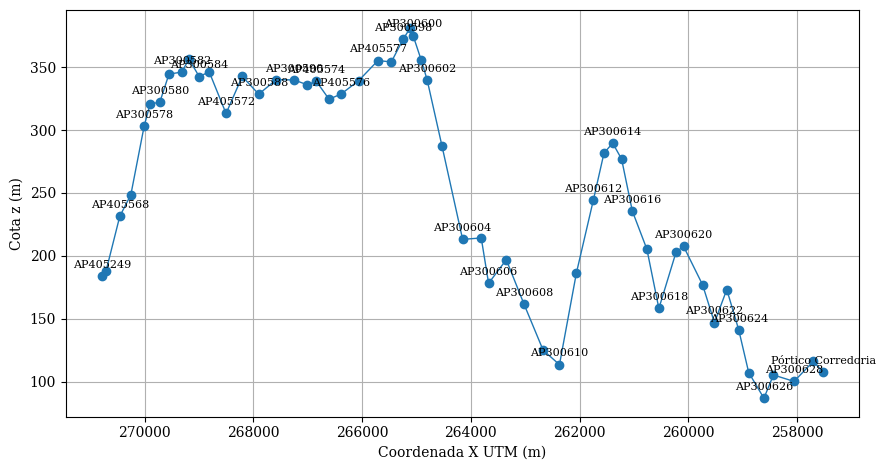

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))

# Eje X = x_m (UTM Easting)
ax.plot(work["x_m"], work["z_m"], marker="o", linewidth=1)

ax.set_xlabel("Coordenada X UTM (m)")
ax.set_ylabel("Cota z (m)")

# Invertir eje horizontal
ax.invert_xaxis()

n = len(work)
step = max(1, n // 20)
for i in range(0, n, step):
    ax.annotate(
        work["apoyo"].iloc[i],
        (work["x_m"].iloc[i], work["z_m"].iloc[i]),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8
    )

ax.grid(True)
plt.tight_layout()
fig.savefig(cfg.out_perfil_file, dpi=300, bbox_inches="tight")
plt.show()
